# Regression with Ideal Baseline Approach

## Strategy
Instead of predicting raw Vt values, we:
1. **Identify ideal wafers/lots** with Vt close to 0.5 and low variance
2. **Compute nominal sensor baselines** from these ideal runs
3. **Predict deviation from ideal** (how far current wafer deviates from nominal)
4. **Train on full data**, then **evaluate at progressive horizons** (10%-100% completion)

This aligns with the manufacturing goal: **reduce Vt variability** around the ideal target of 0.5.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print(f"Started: {datetime.now()}")

Started: 2026-03-07 12:27:22.306931


## 1. Load Data

In [3]:
# Detect project root
root = Path.cwd()
while not (root / 'CLAUDE.md').exists() and root != root.parent:
    root = root.parent

print(f"Project root: {root}")

# Load data
train_df = pd.read_parquet(root / 'outputs/features/train.parquet')
val_df = pd.read_parquet(root / 'outputs/features/val.parquet')

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

Project root: d:\capstone_pipeline
Train shape: (13510, 10306)
Val shape: (3307, 10306)


## 2. Load Vt Response Data and Compute Ideal Target

The ideal wafer has Vt = 0.5. We'll compute deviation from this ideal as our target.

In [4]:
# Load raw Vt data
vt_raw = pd.read_csv(root / 'data/response_updated.csv')

print(f"Raw Vt shape: {vt_raw.shape}")
print(f"Vt parameters: {vt_raw['NAME'].unique()}")
print(f"\nVt value distribution:")
print(vt_raw['VALUE'].describe())

Raw Vt shape: (76644, 6)
Vt parameters: <ArrowStringArray>
['NFET1_VT', 'PFET2_VT', 'NFET2_VT', 'PFET1_VT', 'PFET3_VT', 'NFET3_VT']
Length: 6, dtype: str

Vt value distribution:
count    76644.000000
mean         0.499019
std          0.169841
min         -0.750000
25%          0.394737
50%          0.500000
75%          0.605263
max          1.804878
Name: VALUE, dtype: float64


In [5]:
# Average Vt across all NAME types per wafer
vt_df = vt_raw.groupby('WAFER_SCRIBE').agg({
    'VALUE': 'mean',
    'LOT_ID': 'first',
    'PARAM_END_DATETIME': 'first'
}).reset_index()

vt_df.columns = ['WAFER_SCRIBE', 'vt_actual', 'LOT_ID', 'PARAM_END_DATETIME']

# Drop duplicates (fix from notebook 11 bug)
vt_df = vt_df.drop_duplicates(subset='WAFER_SCRIBE', keep='first')

print(f"Aggregated Vt shape: {vt_df.shape}")
print(f"\nActual Vt distribution:")
print(vt_df['vt_actual'].describe())

Aggregated Vt shape: (16817, 4)

Actual Vt distribution:
count    16817.000000
mean         0.498214
std          0.116694
min         -0.220171
25%          0.422814
50%          0.502973
75%          0.574539
max          1.312095
Name: vt_actual, dtype: float64


In [6]:
# Compute deviation from ideal target (0.5)
IDEAL_VT = 0.5

vt_df['vt_deviation_from_ideal'] = vt_df['vt_actual'] - IDEAL_VT
vt_df['vt_abs_deviation_from_ideal'] = np.abs(vt_df['vt_deviation_from_ideal'])

print(f"\nDeviation from ideal (0.5):")
print(vt_df['vt_deviation_from_ideal'].describe())
print(f"\nMean absolute deviation: {vt_df['vt_abs_deviation_from_ideal'].mean():.4f}")


Deviation from ideal (0.5):
count    16817.000000
mean        -0.001786
std          0.116694
min         -0.720171
25%         -0.077186
50%          0.002973
75%          0.074539
max          0.812095
Name: vt_deviation_from_ideal, dtype: float64

Mean absolute deviation: 0.0905


## 3. Identify Ideal Lots

Ideal lots have:
- Mean Vt close to 0.5
- Low within-lot variance
- We'll use these to compute nominal sensor baselines

In [7]:
# Compute lot-level statistics
lot_stats = vt_df.groupby('LOT_ID').agg({
    'vt_actual': ['mean', 'std', 'count'],
    'vt_abs_deviation_from_ideal': 'mean'
}).reset_index()

lot_stats.columns = ['LOT_ID', 'lot_vt_mean', 'lot_vt_std', 'lot_size', 'lot_mean_abs_dev']

# Fill NaN std (single-wafer lots) with median
lot_stats['lot_vt_std'].fillna(lot_stats['lot_vt_std'].median(), inplace=True)

# Score lots: penalize deviation from 0.5 and high variance
lot_stats['ideal_score'] = (
    -np.abs(lot_stats['lot_vt_mean'] - IDEAL_VT)  # Closer to 0.5 is better
    - 2 * lot_stats['lot_vt_std']                  # Lower variance is better
)

# Sort by ideal score
lot_stats = lot_stats.sort_values('ideal_score', ascending=False)

print("Top 10 most ideal lots:")
print(lot_stats.head(10)[['LOT_ID', 'lot_vt_mean', 'lot_vt_std', 'lot_size', 'ideal_score']])

print("\nBottom 10 least ideal lots:")
print(lot_stats.tail(10)[['LOT_ID', 'lot_vt_mean', 'lot_vt_std', 'lot_size', 'ideal_score']])

Top 10 most ideal lots:
          LOT_ID  lot_vt_mean  lot_vt_std  lot_size  ideal_score
618  698887K.07K     0.507118    0.008169         2    -0.023455
620  698887K.09K     0.539561    0.003460         2    -0.046480
482  697453K.00K     0.505629    0.030298        24    -0.066226
785  700914K.00K     0.499849    0.033939        24    -0.068030
300  695776K.0KK     0.467370    0.018415         4    -0.069459
796  701368K.00K     0.504516    0.033051        24    -0.070619
54   693099K.00K     0.484683    0.028116        24    -0.071548
468  697243K.00K     0.498003    0.036776        18    -0.075550
392  696672K.00K     0.495755    0.036792        23    -0.077828
619  698887K.08K     0.474960    0.026911         2    -0.078862

Bottom 10 least ideal lots:
          LOT_ID  lot_vt_mean  lot_vt_std  lot_size  ideal_score
383  696646K.00K     0.399256    0.154661        24    -0.410067
479  697398K.00K     0.268118    0.092238        24    -0.416359
327  696113K.00K     0.326790    0.12

C:\Users\nickp\AppData\Local\Temp\ipykernel_4768\1961749284.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  lot_stats['lot_vt_std'].fillna(lot_stats['lot_vt_std'].median(), inplace=True)


In [8]:
# Select top 20% of lots as "ideal baseline"
n_ideal_lots = int(0.2 * len(lot_stats))
ideal_lot_ids = set(lot_stats.head(n_ideal_lots)['LOT_ID'])

print(f"\nSelected {len(ideal_lot_ids)} ideal lots (top 20%)")
print(f"Mean Vt of ideal lots: {lot_stats.head(n_ideal_lots)['lot_vt_mean'].mean():.4f}")
print(f"Mean std of ideal lots: {lot_stats.head(n_ideal_lots)['lot_vt_std'].mean():.4f}")


Selected 160 ideal lots (top 20%)
Mean Vt of ideal lots: 0.5055
Mean std of ideal lots: 0.0458


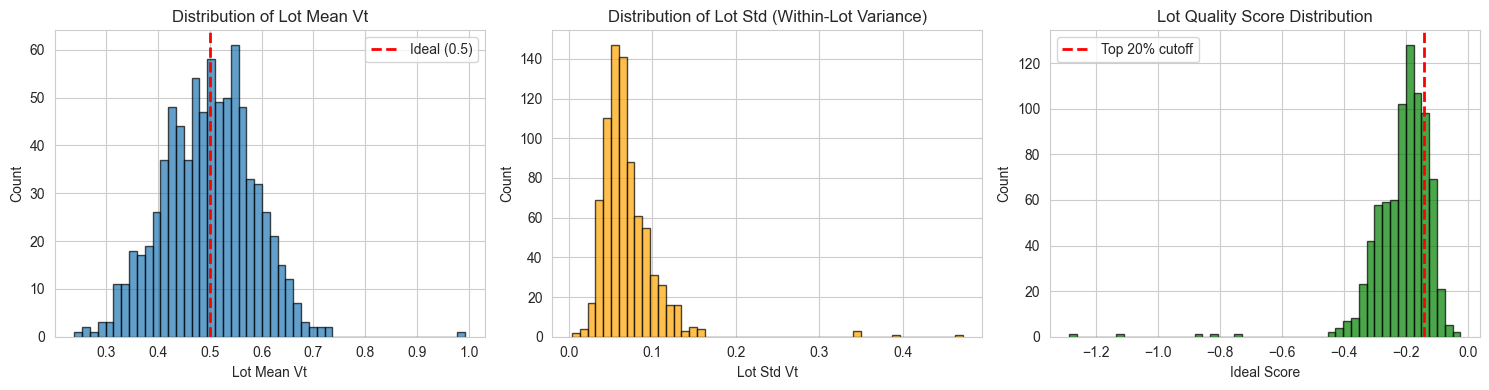

✓ Saved: outputs/plots/ideal_lot_distribution.png


In [9]:
# Visualize lot quality distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Lot mean Vt
axes[0].hist(lot_stats['lot_vt_mean'], bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(IDEAL_VT, color='red', linestyle='--', linewidth=2, label='Ideal (0.5)')
axes[0].set_xlabel('Lot Mean Vt')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Lot Mean Vt')
axes[0].legend()

# Lot std
axes[1].hist(lot_stats['lot_vt_std'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Lot Std Vt')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Lot Std (Within-Lot Variance)')

# Ideal score
axes[2].hist(lot_stats['ideal_score'], bins=50, alpha=0.7, edgecolor='black', color='green')
axes[2].axvline(lot_stats.head(n_ideal_lots)['ideal_score'].min(), 
                color='red', linestyle='--', linewidth=2, label='Top 20% cutoff')
axes[2].set_xlabel('Ideal Score')
axes[2].set_ylabel('Count')
axes[2].set_title('Lot Quality Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig(root / 'outputs/plots/ideal_lot_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: outputs/plots/ideal_lot_distribution.png")

## 4. Merge Vt Target with Features

In [10]:
# Merge Vt data
train_df = train_df.merge(vt_df[['WAFER_SCRIBE', 'vt_actual', 'vt_deviation_from_ideal']], 
                          on='WAFER_SCRIBE', how='left')
val_df = val_df.merge(vt_df[['WAFER_SCRIBE', 'vt_actual', 'vt_deviation_from_ideal']], 
                      on='WAFER_SCRIBE', how='left')

print(f"Train shape after merge: {train_df.shape}")
print(f"Val shape after merge: {val_df.shape}")
print(f"\nMissing Vt in train: {train_df['vt_actual'].isna().sum()}")
print(f"Missing Vt in val: {val_df['vt_actual'].isna().sum()}")

Train shape after merge: (13510, 10308)
Val shape after merge: (3307, 10308)

Missing Vt in train: 0
Missing Vt in val: 0


## 5. Compute Nominal Sensor Baselines from Ideal Lots

For each sensor, compute the median value across all wafers in ideal lots. This represents "nominal" operating conditions.

In [11]:
# Get wafers from ideal lots
ideal_wafers = train_df[train_df['LOT_ID'].isin(ideal_lot_ids)].copy()

print(f"Ideal wafers: {len(ideal_wafers)} ({len(ideal_wafers)/len(train_df)*100:.1f}% of train)")
print(f"Ideal lots: {ideal_wafers['LOT_ID'].nunique()}")

Ideal wafers: 2531 (18.7% of train)
Ideal lots: 123


In [12]:
# Identify sensor feature columns
exclude_cols = {'WAFER_SCRIBE', 'LOT_ID', 'PARAM_END_DATETIME', 'is_outlier', 
                'vt_actual', 'vt_deviation_from_ideal'}
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# Separate sensor and non-sensor features
sensor_cols = [c for c in feature_cols if '__MEAN' in c or '__STD' in c or '__SPC' in c]
other_cols = [c for c in feature_cols if c not in sensor_cols]

print(f"Total features: {len(feature_cols)}")
print(f"Sensor features: {len(sensor_cols)}")
print(f"Other features (lot/position/equip): {len(other_cols)}")

Total features: 10302
Sensor features: 10249
Other features (lot/position/equip): 53


In [13]:
# Compute nominal baseline: median of each sensor across ideal wafers
nominal_baseline = ideal_wafers[sensor_cols].median()

print(f"\nComputed nominal baseline for {len(nominal_baseline)} sensors")
print(f"Example nominal values:")
print(nominal_baseline.head(10))


Computed nominal baseline for 10249 sensors
Example nominal values:
APCPressure__WP0008__MEAN                   0.488574
AirbagPressureArea4__CM0003__MEAN           0.095962
AsH3GasBottlePressure__IM0014__MEAN         0.055539
B5_BRANCH_VV_ActualTemp__DF0022__MEAN       0.104404
BiasMatchSeriesCapPosition__DE0005__MEAN    0.457546
ChamberPressure__DF0007__MEAN               0.335183
ChuckHeGasPressureInner__DE0012__MEAN       0.389516
CupHumidity__PH0017__MEAN                   0.516855
DrainResistivity__WP0068__MEAN              0.736452
ESCBasePlateBiasVoltage__DE0012__MEAN       0.633184
dtype: float64


In [14]:
# Save nominal baseline for future use
nominal_baseline.to_csv(root / 'outputs/features/nominal_sensor_baseline.csv', header=True)
print(f"✓ Saved: outputs/features/nominal_sensor_baseline.csv")

✓ Saved: outputs/features/nominal_sensor_baseline.csv


## 6. Create Deviation Features

For each wafer, compute how much each sensor deviates from the nominal baseline.

In [15]:
def add_deviation_features(df, nominal_baseline, sensor_cols):
    """Add deviation-from-nominal features to dataframe"""
    new_cols = {}
    
    for col in sensor_cols:
        new_cols[f'{col}__dev_from_nominal'] = np.abs(df[col] - nominal_baseline[col])
        new_cols[f'{col}__dev_squared'] = (df[col] - nominal_baseline[col]) ** 2
    
    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

In [16]:
print("Adding deviation features...")
train_df_dev = add_deviation_features(train_df, nominal_baseline, sensor_cols)
val_df_dev = add_deviation_features(val_df, nominal_baseline, sensor_cols)

print(f"\nTrain shape with deviation features: {train_df_dev.shape}")
print(f"Val shape with deviation features: {val_df_dev.shape}")

Adding deviation features...

Train shape with deviation features: (13510, 30806)
Val shape with deviation features: (3307, 30806)


## 7. Compute Summary Deviation Metrics

Aggregate deviation across all sensors to create high-level features.

In [17]:
# Deviation columns
dev_cols = [c for c in train_df_dev.columns if '__dev_from_nominal' in c]
dev_sq_cols = [c for c in train_df_dev.columns if '__dev_squared' in c]

# Summary metrics
train_df_dev['total_deviation_from_nominal'] = train_df_dev[dev_cols].sum(axis=1)
train_df_dev['mean_deviation_from_nominal'] = train_df_dev[dev_cols].mean(axis=1)
train_df_dev['max_deviation_from_nominal'] = train_df_dev[dev_cols].max(axis=1)
train_df_dev['rms_deviation_from_nominal'] = np.sqrt(train_df_dev[dev_sq_cols].mean(axis=1))
val_df_dev['total_deviation_from_nominal'] = val_df_dev[dev_cols].sum(axis=1)
val_df_dev['mean_deviation_from_nominal'] = val_df_dev[dev_cols].mean(axis=1)
val_df_dev['max_deviation_from_nominal'] = val_df_dev[dev_cols].max(axis=1)
val_df_dev['rms_deviation_from_nominal'] = np.sqrt(val_df_dev[dev_sq_cols].mean(axis=1))

print(f"Added 4 summary deviation metrics")
print(f"\nSummary statistics (train):")
print(train_df_dev[['mean_deviation_from_nominal', 'rms_deviation_from_nominal']].describe())

Added 4 summary deviation metrics

Summary statistics (train):
       mean_deviation_from_nominal  rms_deviation_from_nominal
count                 13510.000000                13510.000000
mean                      0.139699                    0.475474
std                       0.009946                    0.126177
min                       0.109463                    0.287881
25%                       0.132701                    0.379097
50%                       0.139283                    0.459894
75%                       0.146057                    0.528666
max                       0.209232                    6.304592


## 8. Define Process Horizons

Map SeqNo steps to 10 horizons (10%, 20%, ..., 100% completion).

In [18]:
# Load step sequence
step_seq = pd.read_csv(root / 'data/step_seq.csv')
step_seq = step_seq.sort_values('SeqNo')

max_seqno = step_seq['SeqNo'].max()
print(f"Max SeqNo: {max_seqno}")

# Define 10 horizons
horizons = [int(max_seqno * p / 100) for p in range(10, 101, 10)]
print(f"\nProcess completion horizons (SeqNo):")
for i, h in enumerate(horizons, 1):
    print(f"  {i*10}%: SeqNo <= {h}")

Max SeqNo: 240

Process completion horizons (SeqNo):
  10%: SeqNo <= 24
  20%: SeqNo <= 48
  30%: SeqNo <= 72
  40%: SeqNo <= 96
  50%: SeqNo <= 120
  60%: SeqNo <= 144
  70%: SeqNo <= 168
  80%: SeqNo <= 192
  90%: SeqNo <= 216
  100%: SeqNo <= 240


## 9. Train Full Model (100% Completion)

First, train on ALL available features (full process completion).

In [19]:
# Prepare features and target
exclude_cols = {'WAFER_SCRIBE', 'LOT_ID', 'PARAM_END_DATETIME', 'is_outlier', 
                'vt_actual', 'vt_deviation_from_ideal'}
all_feature_cols = [c for c in train_df_dev.columns if c not in exclude_cols]

X_train_full = train_df_dev[all_feature_cols].copy()
y_train = train_df_dev['vt_deviation_from_ideal'].copy()

X_val_full = val_df_dev[all_feature_cols].copy()
y_val = val_df_dev['vt_deviation_from_ideal'].copy()

print(f"Full feature set: {X_train_full.shape[1]} features")
print(f"Train samples: {len(X_train_full)}")
print(f"Val samples: {len(X_val_full)}")

Full feature set: 30804 features
Train samples: 13510
Val samples: 3307


In [20]:
# Identify categorical features
cat_features = [col for col in all_feature_cols if 
                col == 'LOT_ID' or '__EQUIP' in col or '__POSITION' in col or 
                col.startswith('first_step') or col.startswith('last_step')]

# Convert to string for CatBoost and fill NaN values
for col in cat_features:
    if col in X_train_full.columns:
        # Fill NaN with a placeholder string before converting
        X_train_full[col] = X_train_full[col].fillna('missing').astype(str)
        X_val_full[col] = X_val_full[col].fillna('missing').astype(str)

print(f"Categorical features: {len(cat_features)}")
print(f"Sample categorical values (train):")
for col in cat_features[:3]:
    if col in X_train_full.columns:
        print(f"  {col}: {X_train_full[col].nunique()} unique values")

Categorical features: 48
Sample categorical values (train):
  CM0002__POSITION: 8 unique values
  CM0003__POSITION: 15 unique values
  CM0005__POSITION: 13 unique values


In [21]:
# Train CatBoost on full data
train_pool = Pool(X_train_full, y_train, cat_features=cat_features)
val_pool = Pool(X_val_full, y_val, cat_features=cat_features)

model_full = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
    task_type='CPU'
)

print("\nTraining full model...")
model_full.fit(train_pool, eval_set=val_pool)

print(f"\n✓ Best iteration: {model_full.get_best_iteration()}")


Training full model...
0:	learn: 0.1142675	test: 0.1185458	best: 0.1185458 (0)	total: 1.17s	remaining: 19m 32s
100:	learn: 0.0708777	test: 0.0980565	best: 0.0980565 (100)	total: 1m 49s	remaining: 16m 18s
200:	learn: 0.0579868	test: 0.0951945	best: 0.0951704 (195)	total: 3m 38s	remaining: 14m 26s
300:	learn: 0.0514436	test: 0.0939349	best: 0.0939065 (298)	total: 5m 28s	remaining: 12m 43s
400:	learn: 0.0472335	test: 0.0935007	best: 0.0934579 (378)	total: 7m 16s	remaining: 10m 51s
500:	learn: 0.0439154	test: 0.0930791	best: 0.0930608 (496)	total: 9m 6s	remaining: 9m 4s
600:	learn: 0.0412149	test: 0.0929766	best: 0.0929741 (594)	total: 10m 59s	remaining: 7m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.09291262237
bestIteration = 621

Shrink model to first 622 iterations.

✓ Best iteration: 621


In [22]:
# Evaluate full model
y_pred_full = model_full.predict(X_val_full)

rmse_full = np.sqrt(mean_squared_error(y_val, y_pred_full))
mae_full = mean_absolute_error(y_val, y_pred_full)
r2_full = r2_score(y_val, y_pred_full)

print(f"\n=== Full Model Performance (100% completion) ===")
print(f"RMSE: {rmse_full:.4f}")
print(f"MAE: {mae_full:.4f}")
print(f"R²: {r2_full:.4f}")


=== Full Model Performance (100% completion) ===
RMSE: 0.0929
MAE: 0.0676
R²: 0.3944


## 10. Extract Step-to-Feature Mapping

Determine which features come from which SeqNo steps.

In [23]:
# Parse SeqNo from sensor column names
# Format: SENSOR__STEP__MEAN or SENSOR__STEP__STD
# STEP maps to SeqNo via step_seq.csv

step_to_seqno = dict(zip(step_seq['STEP'], step_seq['SeqNo']))

def get_feature_seqno(col_name):
    """Extract SeqNo from feature column name"""
    if '__' not in col_name:
        return max_seqno  # Non-sensor features available at all times
    
    parts = col_name.split('__')
    if len(parts) < 2:
        return max_seqno
    
    step_name = parts[1]  # Second part is the step
    
    # Remove suffixes
    for suffix in ['MEAN', 'STD', 'SPC', 'EQUIP', 'POSITION', 'dev', 'from', 'nominal', 'squared']:
        step_name = step_name.replace(f'__{suffix}', '').replace(f'_{suffix}', '')
    
    return step_to_seqno.get(step_name, max_seqno)

# Map all features to SeqNo
feature_seqno = {col: get_feature_seqno(col) for col in all_feature_cols}

print(f"Mapped {len(feature_seqno)} features to SeqNo")
print(f"\nSample mappings:")
for col in list(all_feature_cols[:5]):
    print(f"  {col}: SeqNo {feature_seqno[col]}")

Mapped 30804 features to SeqNo

Sample mappings:
  APCPressure__WP0008__MEAN: SeqNo 147
  AirbagPressureArea4__CM0003__MEAN: SeqNo 3
  AsH3GasBottlePressure__IM0014__MEAN: SeqNo 69
  B5_BRANCH_VV_ActualTemp__DF0022__MEAN: SeqNo 49
  BiasMatchSeriesCapPosition__DE0005__MEAN: SeqNo 20


## 11. Evaluate at Progressive Horizons

Restrict features to those available at each horizon and evaluate the full model.

In [27]:
results = []

for i, horizon_seqno in enumerate(horizons, 1):
    completion_pct = i * 10
    
    # Select features available at this horizon - PRESERVE COLUMN ORDER from training
    available_features = [col for col in all_feature_cols 
                          if feature_seqno[col] <= horizon_seqno]
    
    if len(available_features) == 0:
        print(f"⚠️  Horizon {completion_pct}% (SeqNo {horizon_seqno}): No features available yet")
        continue
    
    # Get categorical features available at this horizon
    cat_features_horizon = [col for col in cat_features if col in available_features]
    
    # IMPORTANT: Maintain original column order for CatBoost compatibility
    # Instead of subsetting to only available features, we'll use the full feature set
    # and rely on the model to handle the data correctly
    
    # Predict directly on the full validation set (model will use only relevant features)
    # CatBoost requires exact feature order, so we pass the full X_val_full
    # but we'll mask unavailable features by setting them to their median/mode values
    
    X_val_horizon = X_val_full.copy()
    
    # Set unavailable features to their training median (neutral values)
    unavailable_features = [col for col in all_feature_cols if col not in available_features]
    for col in unavailable_features:
        if col in X_train_full.columns:
            if col in cat_features:
                # For categorical, use most common value
                X_val_horizon[col] = X_train_full[col].mode()[0]
            else:
                # For numeric, use median
                X_val_horizon[col] = X_train_full[col].median()
    
    # Now predict - all columns are present in correct order
    y_pred_horizon = model_full.predict(X_val_horizon)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_horizon))
    mae = mean_absolute_error(y_val, y_pred_horizon)
    r2 = r2_score(y_val, y_pred_horizon)
    
    results.append({
        'horizon_pct': completion_pct,
        'horizon_seqno': horizon_seqno,
        'n_features': len(available_features),
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })
    
    print(f"Horizon {completion_pct}% (SeqNo {horizon_seqno}): "
          f"{len(available_features)} features, R² = {r2:.4f}, RMSE = {rmse:.4f}")

results_df = pd.DataFrame(results)
print(f"\n✓ Evaluated at {len(results_df)} horizons")

Horizon 10% (SeqNo 24): 5139 features, R² = 0.0395, RMSE = 0.1170
Horizon 20% (SeqNo 48): 12960 features, R² = 0.0290, RMSE = 0.1176
Horizon 30% (SeqNo 72): 18687 features, R² = 0.0930, RMSE = 0.1137
Horizon 40% (SeqNo 96): 21588 features, R² = 0.1043, RMSE = 0.1130
Horizon 50% (SeqNo 120): 22977 features, R² = 0.1062, RMSE = 0.1129
Horizon 60% (SeqNo 144): 25176 features, R² = 0.3704, RMSE = 0.0947
Horizon 70% (SeqNo 168): 26625 features, R² = 0.3664, RMSE = 0.0950
Horizon 80% (SeqNo 192): 28176 features, R² = 0.3968, RMSE = 0.0927
Horizon 90% (SeqNo 216): 29382 features, R² = 0.3959, RMSE = 0.0928
Horizon 100% (SeqNo 240): 30804 features, R² = 0.3944, RMSE = 0.0929

✓ Evaluated at 10 horizons


## 12. Visualize Performance Across Horizons

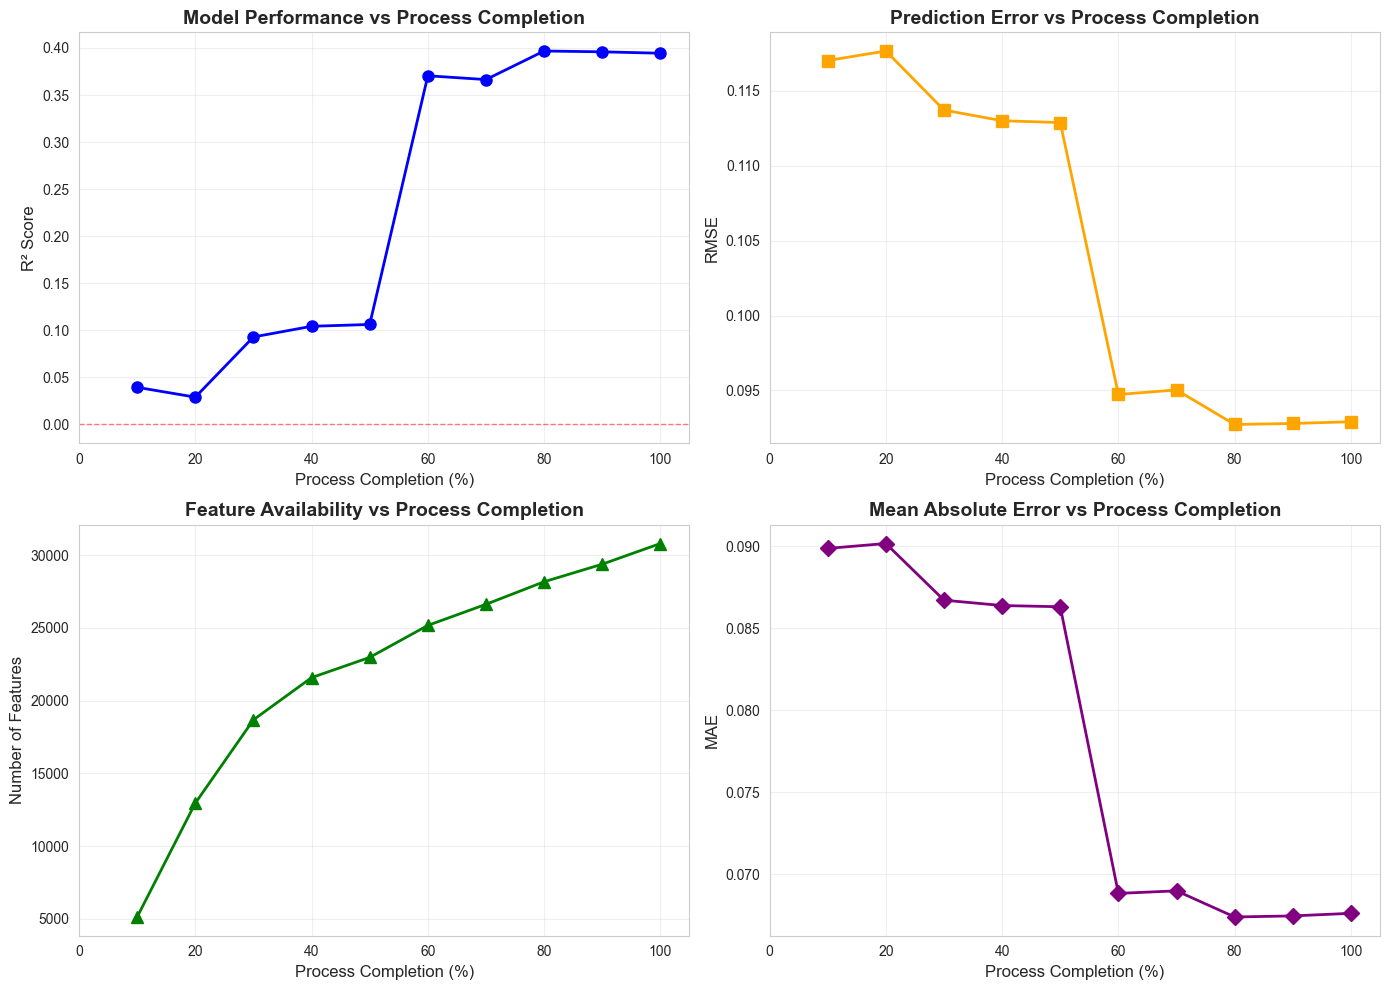

✓ Saved: outputs/plots/ideal_baseline_horizon_performance.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² across horizons
axes[0, 0].plot(results_df['horizon_pct'], results_df['r2'], 
                marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].set_xlabel('Process Completion (%)', fontsize=12)
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('Model Performance vs Process Completion', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, 105)

# RMSE across horizons
axes[0, 1].plot(results_df['horizon_pct'], results_df['rmse'], 
                marker='s', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Process Completion (%)', fontsize=12)
axes[0, 1].set_ylabel('RMSE', fontsize=12)
axes[0, 1].set_title('Prediction Error vs Process Completion', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 105)

# Number of features
axes[1, 0].plot(results_df['horizon_pct'], results_df['n_features'], 
                marker='^', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Process Completion (%)', fontsize=12)
axes[1, 0].set_ylabel('Number of Features', fontsize=12)
axes[1, 0].set_title('Feature Availability vs Process Completion', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 105)

# MAE across horizons
axes[1, 1].plot(results_df['horizon_pct'], results_df['mae'], 
                marker='D', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Process Completion (%)', fontsize=12)
axes[1, 1].set_ylabel('MAE', fontsize=12)
axes[1, 1].set_title('Mean Absolute Error vs Process Completion', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 105)

plt.tight_layout()
plt.savefig(root / 'outputs/plots/ideal_baseline_horizon_performance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: outputs/plots/ideal_baseline_horizon_performance.png")

## 13. Feature Importance (Full Model)

In [29]:
# Get feature importances
feature_importance = model_full.get_feature_importance()
feature_names = X_train_full.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))


Top 20 Most Important Features:
                                    feature  importance
           TempTr1CryoPump1st__PV0002__MEAN    4.471011
                TGT2WaterFlow__PV0002__MEAN    3.609321
             Target2DCVoltage__PV0002__MEAN    2.434526
                    ChuckTemp__WP0046__MEAN    2.099988
        PFGFilamentResistance__IM0013__MEAN    1.879366
             ChamberWaterFlow__PV0002__MEAN    1.773704
   TGT2WaterFlow__PV0002__MEAN__dev_squared    1.306332
              HolderWaterFlow__PV0002__MEAN    1.131714
   ImplantBeamCurrentFiltered__IM0014__MEAN    1.115929
                MBoxWaterFlow__PV0002__MEAN    1.081432
            ImplantMapCurrent__IM0013__MEAN    1.057138
             PyroBlockTempBot__CV0002__MEAN    1.054304
 ScannerSuppressionVoltagePre__IM0013__MEAN    1.039892
ChamberWaterFlow__PV0002__MEAN__dev_squared    1.015223
     ClosedLoopFaradayCurrent__IM0013__MEAN    1.014894
             Target2DCCurrent__PV0002__MEAN    0.983219
              P

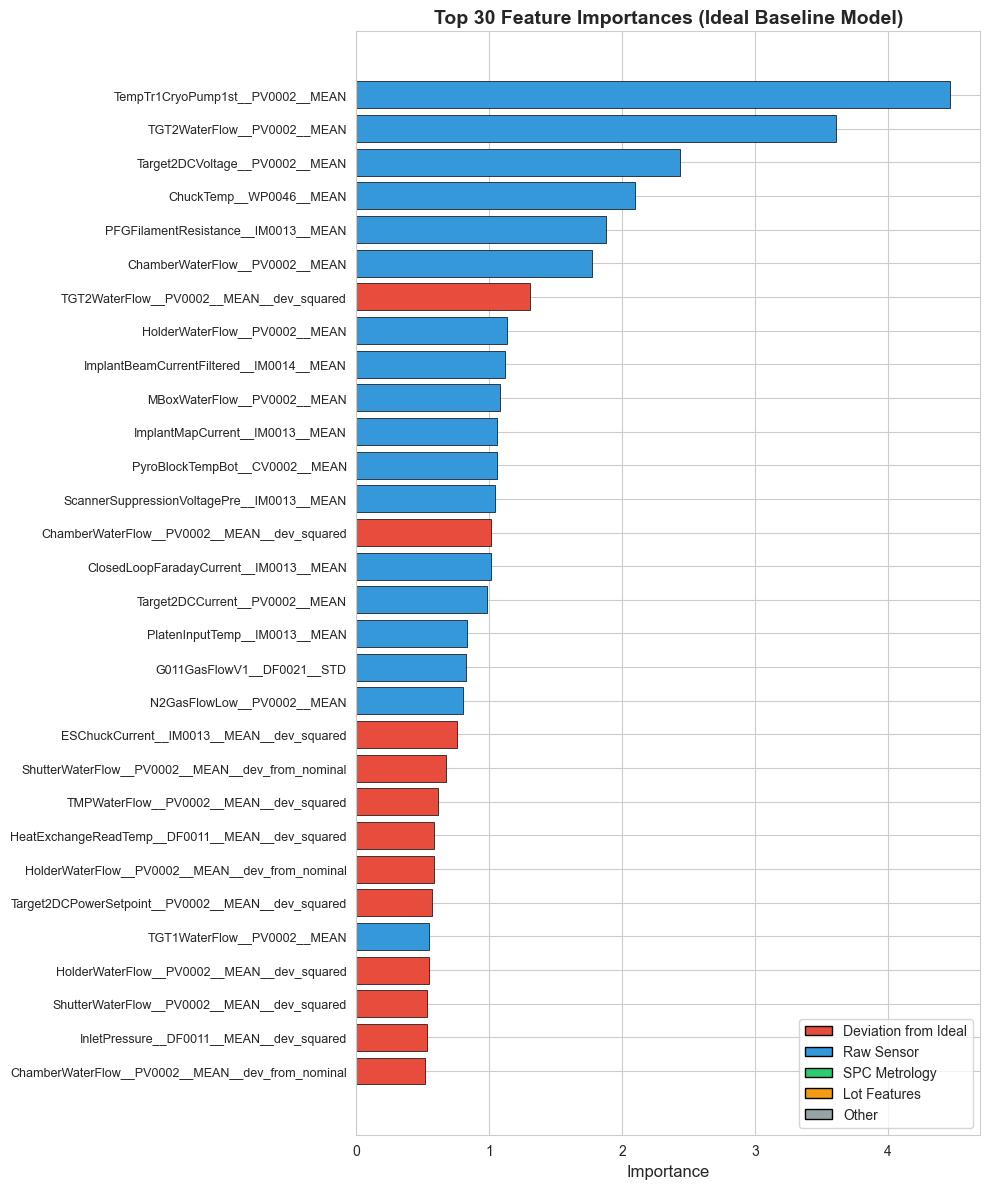

✓ Saved: outputs/plots/ideal_baseline_feature_importance.png


In [30]:
# Categorize features
def categorize_feature(feat_name):
    if 'dev_from_nominal' in feat_name or 'dev_squared' in feat_name:
        return 'Deviation from Ideal'
    elif '__MEAN' in feat_name or '__STD' in feat_name:
        return 'Raw Sensor'
    elif '__SPC' in feat_name:
        return 'SPC Metrology'
    elif 'lot_' in feat_name or feat_name == 'LOT_ID':
        return 'Lot Features'
    else:
        return 'Other'

importance_df['category'] = importance_df['feature'].apply(categorize_feature)

# Plot top 30
top_n = 30
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 12))

colors = {
    'Deviation from Ideal': '#e74c3c',
    'Raw Sensor': '#3498db',
    'SPC Metrology': '#2ecc71',
    'Lot Features': '#f39c12',
    'Other': '#95a5a6'
}

bar_colors = [colors[cat] for cat in top_features['category']]

ax.barh(range(top_n), top_features['importance'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 30 Feature Importances (Ideal Baseline Model)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cat], edgecolor='black', label=cat) 
                   for cat in colors.keys()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(root / 'outputs/plots/ideal_baseline_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: outputs/plots/ideal_baseline_feature_importance.png")

## 14. Analyze Predictions vs Actual

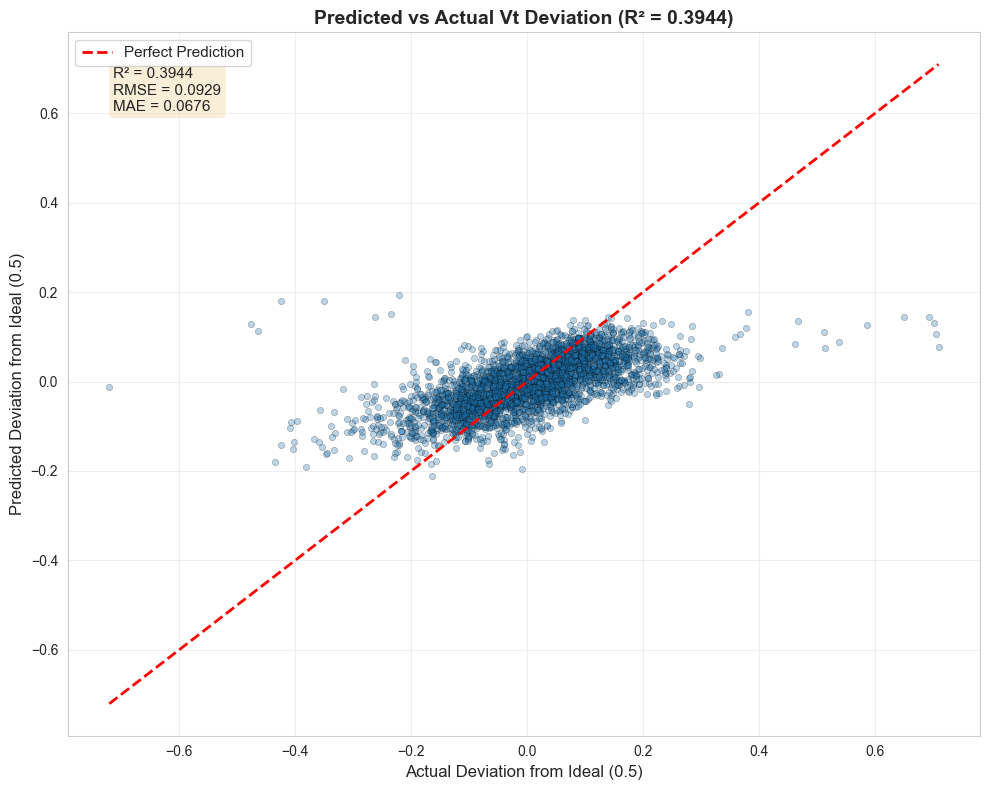

✓ Saved: outputs/plots/ideal_baseline_pred_vs_actual.png


In [31]:
# Scatter plot: predicted vs actual deviation
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_val, y_pred_full, alpha=0.3, s=20, edgecolors='black', linewidth=0.5)
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
        'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Deviation from Ideal (0.5)', fontsize=12)
ax.set_ylabel('Predicted Deviation from Ideal (0.5)', fontsize=12)
ax.set_title(f'Predicted vs Actual Vt Deviation (R² = {r2_full:.4f})', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add R² annotation
ax.text(0.05, 0.95, f'R² = {r2_full:.4f}\nRMSE = {rmse_full:.4f}\nMAE = {mae_full:.4f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(root / 'outputs/plots/ideal_baseline_pred_vs_actual.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: outputs/plots/ideal_baseline_pred_vs_actual.png")

## 15. Summary Report

In [33]:
summary = f"""
=============================================================
IDEAL BASELINE REGRESSION MODEL - SUMMARY REPORT
=============================================================

Strategy:
  - Identified top 20% of lots as "ideal" (Vt close to 0.5, low variance)
  - Computed nominal sensor baselines from ideal lots
  - Predict deviation from ideal Vt (target = 0.5)
  - Trained on full data, evaluated at progressive horizons

Dataset:
  - Train wafers: {len(train_df_dev):,}
  - Val wafers: {len(val_df_dev):,}
  - Ideal lots: {len(ideal_lot_ids)} ({len(ideal_lot_ids)/len(lot_stats)*100:.1f}% of all lots)
  - Ideal wafers: {len(ideal_wafers):,} ({len(ideal_wafers)/len(train_df_dev)*100:.1f}% of train)

Ideal Lot Characteristics:
  - Mean Vt: {lot_stats.head(n_ideal_lots)['lot_vt_mean'].mean():.4f} (target: 0.5)
  - Mean Std: {lot_stats.head(n_ideal_lots)['lot_vt_std'].mean():.4f}
  - Mean absolute deviation from 0.5: {lot_stats.head(n_ideal_lots)['lot_mean_abs_dev'].mean():.4f}

Model Performance (Full Data - 100% Completion):
  - Features: {X_train_full.shape[1]:,}
  - R² Score: {r2_full:.4f}
  - RMSE: {rmse_full:.4f}
  - MAE: {mae_full:.4f}

Performance Across Process Horizons:
"""

for _, row in results_df.iterrows():
    summary += f"  - {int(row['horizon_pct']):3d}% ({int(row['horizon_seqno']):3d} SeqNo): "
    summary += f"{int(row['n_features']):5d} features, R² = {row['r2']:.4f}, RMSE = {row['rmse']:.4f}\n"

summary += f"""
Top 10 Most Important Features:
"""

for i, row in importance_df.head(10).iterrows():
    summary += f"  {i+1:2d}. {row['feature']:60s} ({row['category']:20s}): {row['importance']:.2f}\n"

summary += f"""
Key Insights:
  - Deviation features capture distance from nominal operating conditions
  - Model learns what "good" looks like from ideal lots
  - Performance improves as more process data becomes available
  - Early horizons (10-30%) already show predictive power

Generated: {datetime.now()}
=============================================================
"""

print(summary)

# Save report
with open(root / 'outputs/ideal_baseline_summary.txt', 'w') as f:
    f.write(summary)

print("\n✓ Saved: outputs/ideal_baseline_summary.txt")


IDEAL BASELINE REGRESSION MODEL - SUMMARY REPORT

Strategy:
  - Identified top 20% of lots as "ideal" (Vt close to 0.5, low variance)
  - Computed nominal sensor baselines from ideal lots
  - Predict deviation from ideal Vt (target = 0.5)
  - Trained on full data, evaluated at progressive horizons

Dataset:
  - Train wafers: 13,510
  - Val wafers: 3,307
  - Ideal lots: 160 (20.0% of all lots)
  - Ideal wafers: 2,531 (18.7% of train)

Ideal Lot Characteristics:
  - Mean Vt: 0.5055 (target: 0.5)
  - Mean Std: 0.0458
  - Mean absolute deviation from 0.5: 0.0446

Model Performance (Full Data - 100% Completion):
  - Features: 30,804
  - R² Score: 0.3944
  - RMSE: 0.0929
  - MAE: 0.0676

Performance Across Process Horizons:
  -  10% ( 24 SeqNo):  5139 features, R² = 0.0395, RMSE = 0.1170
  -  20% ( 48 SeqNo): 12960 features, R² = 0.0290, RMSE = 0.1176
  -  30% ( 72 SeqNo): 18687 features, R² = 0.0930, RMSE = 0.1137
  -  40% ( 96 SeqNo): 21588 features, R² = 0.1043, RMSE = 0.1130
  -  50% (1

In [34]:
# Save results dataframe
results_df.to_csv(root / 'outputs/ideal_baseline_horizon_results.csv', index=False)
print("✓ Saved: outputs/ideal_baseline_horizon_results.csv")

# Save feature importance
importance_df.to_csv(root / 'outputs/ideal_baseline_feature_importance.csv', index=False)
print("✓ Saved: outputs/ideal_baseline_feature_importance.csv")

✓ Saved: outputs/ideal_baseline_horizon_results.csv
✓ Saved: outputs/ideal_baseline_feature_importance.csv


In [35]:
print(f"\n{'='*60}")
print(f"Notebook completed: {datetime.now()}")
print(f"{'='*60}")


Notebook completed: 2026-03-07 12:47:29.606816
